# Lesson 08: Monitoring, alerting and the incident playbook
**Level:** advanced (capstone) · **Before this:** this lesson uses everything from Lessons 02–07, but each check is
explained again here.

> **How to read this notebook:** you don't need to understand the Python. Read the 🔧 line above each grey code
> box (what the code does, in plain words), then the output and the explanation under it.

### What this lesson is about
In Lessons 02–07 we found twelve incidents **by hand, after the day was over**. A real dealing desk needs to know
**while they're happening**, ideally within seconds.

So the file `bridgelab/monitor.py` turns each check from the earlier lessons into an automatic **rule**. A rule looks
at the data and raises an **alert** (time, severity, what, which LP, which symbol, details) whenever something is
wrong. There are 17 rules:

| Area | Rule: raises an alert when… | From lesson |
|---|---|---|
| **Session** (the FIX connection) | an LP sends a Logout (`35=5`), Logon (`35=A`), TestRequest (`35=1`, "are you there?") or ResendRequest (`35=2`, "send me lost messages again"); a re-sent fill arrives (`43=Y`, PossDupFlag); an LP is completely silent; an LP's clock is off | 02 |
| **Feed** (prices) | one symbol stops updating while the connection is alive (stale); one LP's price is far from the others (spike); the book is crossed (best bid > best ask); spreads widen a lot | 03, 04 |
| **Orders** | an order gets no answer; an LP rejects too much; an LP's round trip gets slow; the bridge itself gets slow; the quantity sent doesn't match the client's lots | 05 |
| **Pricing / conduct** | the markup clients get doesn't match the configuration; slippage is one-sided; a client's trades win too consistently (toxic flow) | 06 |
| **Booking** | the same LP fill (same ExecID, tag 17) is booked twice; the LP's statement has a trade we never received | 07 |

This lesson runs all 17 rules over the session, groups the alerts into **incidents**, **scores** the monitor against
the 12 incidents we know are in the data, and ends with a **playbook**: what to do when each alert fires.

### Words used in this lesson
| Word | Meaning |
|---|---|
| **Alert** | One warning from one rule at one moment |
| **Severity** | How urgent: **CRITICAL** (act now, money at risk), **HIGH** (act soon), **MEDIUM** (look today), **INFO** (good to know) |
| **Incident** | One real problem. One incident often produces several alerts |
| **Detection delay** | Time between the problem starting and the first alert about it |
| **Playbook** | The written list of what to check and do for each type of alert |

🔧 **The code below** runs all 17 rules over the whole session, prints the total number of alerts, and counts the
alerts per severity and rule.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from bridgelab import monitor as M, plotting as P
P.setup()
pd.set_option("display.width", 220, "display.max_columns", 20, "display.max_colwidth", 90, "display.max_rows", 100)

alerts = M.run_all()
print(f"{len(alerts)} alerts")
alerts.groupby(["severity", "rule"]).size().rename("alerts").reset_index().sort_values("severity")

43 alerts


,severity,rule,alerts
0,CRITICAL,booking: duplicate deal,1
1,CRITICAL,feed: LP silent,1
2,CRITICAL,feed: symbol frozen,1
3,CRITICAL,orders: no LP response,3
4,CRITICAL,orders: quantity mapping,1
5,CRITICAL,price: spike vs other LPs,1
6,CRITICAL,recon: LP execution missing at bridge,1
7,CRITICAL,session: Logout,1
8,CRITICAL,session: PossDup execution received,1
16,HIGH,session: TestRequest,1


**Reading the output:** **43 alerts** in 2 hours. The rule names are written `area: what`. For example:
* `booking: duplicate deal` (CRITICAL, 1): the same LP fill booked twice (S05).
* `orders: no LP response` (CRITICAL, 3): the three LP_C orders with no answer (S06).
* `LP: high reject rate` (MEDIUM, 8): one alert per 10-minute window where an LP rejected too much (mostly LP_C, S08).
* `LP: latency degraded` (HIGH, 5): LP_A's slow round trips, one alert per 2-minute window (S07).

43 alerts is too many for one person to read one by one, and many are about the same problem. Next step: group them.

---
## 1. From alerts to incidents

**Grouping rule:** alerts from the **same rule**, for the **same LP and symbol**, less than **11 minutes** apart, are
one incident. (Example: LP_A's 5 latency alerts, 2 minutes apart, become one incident: "LP_A slow from 13:12".) One
incident = one ticket for someone to handle.

🔧 **The code below** groups the alerts and lists the incidents in time order: start, end, severity, rule, LP,
symbol, number of alerts grouped, and the details of the first alert.

In [2]:
incidents = M.group_incidents(alerts)
incidents[["start", "end", "severity", "rule", "lp", "symbol", "alerts", "first_detail"]]

,start,end,severity,rule,lp,symbol,alerts,first_detail
0,2025-10-15 11:29:58.510,2025-10-15 11:29:58.510,MEDIUM,session: clock offset,LP_C,NaN,1,LP clock +25 ms vs ours
1,2025-10-15 11:30:34.405,2025-10-15 11:30:34.405,CRITICAL,orders: quantity mapping,LP_C,XAUUSD,1,129 orders sent with 1 units per lot (expected 100)
2,2025-10-15 11:40:00.000,2025-10-15 11:40:00.000,MEDIUM,LP: high reject rate,LP_C,NaN,1,26% of 23 orders rejected
3,2025-10-15 11:52:13.404,2025-10-15 11:52:13.404,CRITICAL,price: spike vs other LPs,LP_C,EURUSD,1,-49.9 pips from consensus
4,2025-10-15 12:05:05.038,2025-10-15 12:05:05.038,HIGH,price: crossed book,NaN,XAUUSD,1,"bid > ask for 84.9 s, worst -46.5 pips"
5,2025-10-15 12:05:05.687,2025-10-15 12:05:05.687,CRITICAL,feed: symbol frozen,LP_B,XAUUSD,1,no XAUUSD update for 91 s while 181 other updates arrived
6,2025-10-15 12:10:00.000,2025-10-15 12:10:00.000,MEDIUM,LP: high reject rate,LP_B,NaN,1,64% of 25 orders rejected
7,2025-10-15 12:10:00.000,2025-10-15 12:20:00.000,MEDIUM,LP: high reject rate,LP_C,NaN,2,42% of 40 orders rejected
8,2025-10-15 12:30:00.701,2025-10-15 12:30:00.701,HIGH,price: crossed book,NaN,XAUUSD,1,"bid > ask for 1.8 s, worst -49.5 pips"
9,2025-10-15 12:30:00.767,2025-10-15 12:30:00.767,HIGH,price: crossed book,NaN,EURUSD,1,"bid > ask for 1.5 s, worst -19.3 pips"


**43 alerts → 30 incidents.** Reading the list is like reading the day's diary. Some highlights, with the incident each
one belongs to:

| Time | Alert (first detail) | Incident |
|---|---|---|
| 11:29:58.5 | `session: clock offset`, LP_C "clock +25 ms vs ours" | **S12**, found at the morning Logon |
| 11:30:34.4 | `orders: quantity mapping`, LP_C gold "sent with 1 unit per lot (expected 100)" | **S10**, caught on the first gold order to LP_C |
| 11:40:00 | `LP: high reject rate`, LP_C "26% of 23 orders rejected" | **S08** |
| 11:52:13.4 | `price: spike vs other LPs`, LP_C EURUSD "−49.9 pips from consensus" | **S01** |
| 12:05:05 | `price: crossed book` gold, then `feed: symbol frozen` LP_B gold "no update for 91 s while 181 other updates arrived" | **S02** |
| 12:30:00–30 | crossed books, `bridge: processing delay` "median 103 ms", `liquidity: spreads widened` "4.4–4.7× normal" | **S03** (news) |
| 12:40:00.4 | `pricing: markup deviates from config`, GBPUSD "8.0 pips vs configured 0.8" | **S04** |
| 12:45:10 | `booking: duplicate deal`, `session: ResendRequest`, `session: PossDup execution received` | **S05** |
| 13:00:00–13:02:30 | LP execution missing, no LP response, LP silent, TestRequest, Logout, Logon | **S06** (section 3 below) |
| 13:12:00 | `LP: latency degraded`, LP_A "median 428 ms vs normal 7 ms" | **S07** |
| 13:27:48 | `flow: toxic client`, "C1023 (B-book): avg 5 s markout +1.33 pips over 83 fills" | **S11** |
| 13:29:52 | `conduct: asymmetric slippage`, "B-book: 0.0% positive vs 3.6% negative" | **S09** |

🔧 **The code below** draws every alert on a timeline: horizontal = time, vertical = severity. The dotted lines mark
when the incidents S01–S07 started.

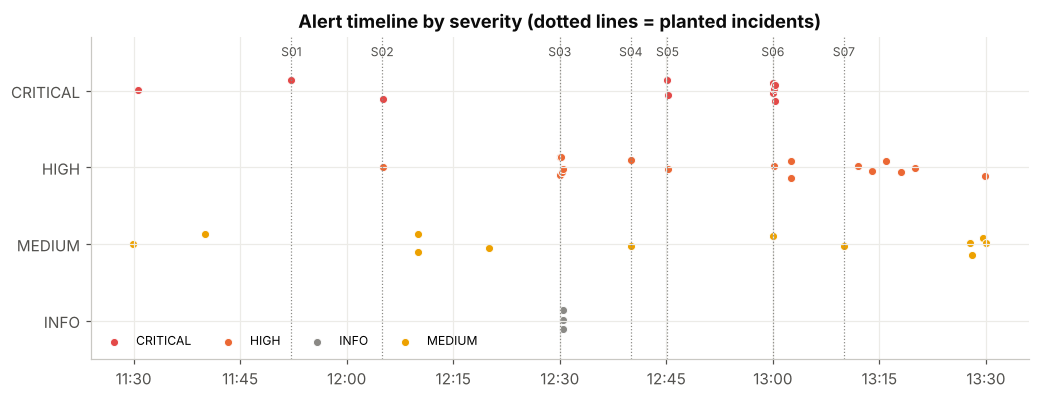

In [3]:
sev_y = {"CRITICAL": 3, "HIGH": 2, "MEDIUM": 1, "INFO": 0}
sev_c = {"CRITICAL": P.ALERT, "HIGH": P.SERIES[1], "MEDIUM": P.SERIES[3], "INFO": P.NEUTRAL}
fig, ax = plt.subplots(figsize=(11, 3.8))
for sev, g in alerts.groupby("severity"):
    ax.scatter(g.time, g.sev_rank + np.random.default_rng(1).uniform(-0.15, 0.15, len(g)), s=28,
               color=sev_c[sev], label=sev, edgecolor="white", linewidth=0.6)
ax.set_yticks(list(sev_y.values()), list(sev_y.keys()))
for t, lab in [("2025-10-15 11:52:13", "S01"), ("2025-10-15 12:05", "S02"), ("2025-10-15 12:30", "S03"),
               ("2025-10-15 12:40", "S04"), ("2025-10-15 12:45:10", "S05"), ("2025-10-15 13:00", "S06"),
               ("2025-10-15 13:10", "S07")]:
    ax.axvline(pd.Timestamp(t), color=P.NEUTRAL, lw=0.8, ls=":")
    ax.text(pd.Timestamp(t), 3.45, lab, fontsize=8, color=P.INK_2, ha="center")
ax.set_ylim(-0.5, 3.7); ax.set_title("Alert timeline by severity (dotted lines = planted incidents)")
P.time_axis(ax); ax.legend(ncol=4, fontsize=8, loc="lower left"); plt.show()

**Reading the chart:** the alerts bunch up right on the dotted lines: each incident is followed immediately by red
(CRITICAL) or orange (HIGH) dots. The busiest moment is 13:00 (the LP_C outage).

---
## 2. Score the monitor: did it catch every incident, and how fast?

Because this data was generated with 12 known incidents (in `bridgelab/simulate.py`), we can **grade** the monitor,
something you can never do perfectly in real life. For each incident we say which alert counts as "caught it" (right
rule, right LP, right symbol), then measure:

> **detection delay** = time of the first matching alert − time the incident started

🔧 **The code below** writes down the 12 incidents (start time and the alert that should catch each one), finds the
first matching alert for each, and shows whether it was detected and the delay in seconds.

In [4]:
truth = pd.DataFrame([
    ("S01", "Bad tick LP_C EURUSD", "2025-10-15 11:52:13.400", "price: spike", "LP_C", "EURUSD"),
    ("S02", "Stale LP_B XAUUSD feed", "2025-10-15 12:05:00", "feed: symbol frozen", "LP_B", "XAUUSD"),
    ("S03", "News: spreads / bridge queue", "2025-10-15 12:30:00", "liquidity: spreads widened", None, None),
    ("S04", "Markup fat finger GBPUSD STD", "2025-10-15 12:39:56.8", "pricing: markup", None, "GBPUSD"),
    ("S05", "Sequence gap -> duplicate deal", "2025-10-15 12:45:10", "booking: duplicate deal", "LP_B", None),
    ("S06", "LP_C session death / lost fill", "2025-10-15 13:00:00", "feed: LP silent", "LP_C", None),
    ("S07", "LP_A latency spike", "2025-10-15 13:10:00", "LP: latency degraded", "LP_A", None),
    ("S08", "LP_C asymmetric last look", "2025-10-15 11:30:00", "LP: high reject rate", "LP_C", None),
    ("S09", "B-book asymmetric slippage", "2025-10-15 11:30:00", "conduct: asymmetric slippage", None, None),
    ("S10", "LP_C gold quantity mapping", "2025-10-15 11:30:00", "orders: quantity mapping", "LP_C", "XAUUSD"),
    ("S11", "Toxic clients", "2025-10-15 11:30:00", "flow: toxic client", None, None),
    ("S12", "LP_C clock offset", "2025-10-15 11:29:58", "session: clock offset", "LP_C", None),
], columns=["scenario", "incident", "start", "rule", "lp", "symbol"])
truth["start"] = pd.to_datetime(truth.start, format="mixed")

def first_hit(r):
    m = alerts.rule.str.startswith(r.rule) & (alerts.time >= r.start - pd.Timedelta(seconds=5))
    if pd.notna(r.lp):
        m &= alerts.lp == r.lp
    if pd.notna(r.symbol):
        m &= alerts.symbol == r.symbol
    hit = alerts[m]
    return hit.time.min() if len(hit) else pd.NaT

truth["first_alert"] = truth.apply(first_hit, axis=1)
truth["detected"] = truth.first_alert.notna()
truth["delay"] = (truth.first_alert - truth.start).dt.total_seconds().round(1)
truth[["scenario", "incident", "start", "first_alert", "detected", "delay"]]

,scenario,incident,start,first_alert,detected,delay
0,S01,Bad tick LP_C EURUSD,2025-10-15 11:52:13.400,2025-10-15 11:52:13.404,True,0.0
1,S02,Stale LP_B XAUUSD feed,2025-10-15 12:05:00.000,2025-10-15 12:05:05.687,True,5.7
2,S03,News: spreads / bridge queue,2025-10-15 12:30:00.000,2025-10-15 12:30:30.000,True,30.0
3,S04,Markup fat finger GBPUSD STD,2025-10-15 12:39:56.800,2025-10-15 12:40:00.440,True,3.6
4,S05,Sequence gap -> duplicate deal,2025-10-15 12:45:10.000,2025-10-15 12:45:10.016,True,0.0
5,S06,LP_C session death / lost fill,2025-10-15 13:00:00.000,2025-10-15 13:00:01.013,True,1.0
6,S07,LP_A latency spike,2025-10-15 13:10:00.000,2025-10-15 13:12:00.000,True,120.0
7,S08,LP_C asymmetric last look,2025-10-15 11:30:00.000,2025-10-15 11:40:00.000,True,600.0
8,S09,B-book asymmetric slippage,2025-10-15 11:30:00.000,2025-10-15 13:29:52.310,True,7192.3
9,S10,LP_C gold quantity mapping,2025-10-15 11:30:00.000,2025-10-15 11:30:34.405,True,34.4


🔧 **The code below** prints the final score.

In [5]:
print(f"Detected {truth.detected.sum()} of {len(truth)} incidents")

Detected 12 of 12 incidents


**All 12 incidents detected.** But look at how **fast**, because the delays fall into three very different groups:

| Speed | Incidents (delay) | Why |
|---|---|---|
| **Within seconds** | S01 bad tick (0 s), S05 duplicate deal (0 s), S12 clock (0.5 s), S06 LP silent (1 s), S04 markup (3.6 s), S02 frozen gold (5.7 s) | each can be seen in **one message** or a few seconds of data |
| **Seconds to minutes** | S03 news (30 s), S10 quantity (34 s: the first gold order to LP_C came 34 s after the open), S07 LP_A latency (2 min), S08 reject rate (10 min) | the rule has to wait for an order to happen, or collect enough orders in a time window to be sure |
| **End of session** | S11 toxic clients, S09 one-sided slippage (~2 hours) | these are **statistical**: you need many trades before you can tell a pattern from bad luck |

**What this teaches:**
* The fast rules can **page someone immediately**, or better, **act automatically** (remove an LP's prices, stop
  routing a symbol).
* The window-based rules are a trade-off: shorter windows find problems faster but raise more false alarms. Every
  desk tunes them.
* The statistical ones belong in **daily/weekly reports**, not in a real-time pager.
* Reconciliation against LP statements normally only happens the next morning. That's why the **real-time** alerts
  for re-sent fills (`43=Y`) and unanswered orders matter: they warn about the same breaks **hours earlier**.

---
## 3. One root cause, many alerts: the LP_C outage (incident S06)

A good monitor doesn't just raise alerts, it helps you see that several alerts are **one problem**.

🔧 **The code below** lists every alert between 12:59:55 and 13:03:00.

In [6]:
alerts[(alerts.time >= "2025-10-15 12:59:55") & (alerts.time <= "2025-10-15 13:03:00")][["time", "severity", "rule", "lp", "symbol", "detail"]]

,time,severity,rule,lp,symbol,detail
22,2025-10-15 13:00:00.000,MEDIUM,LP: high reject rate,LP_C,NaN,32% of 31 orders rejected
23,2025-10-15 13:00:00.089,CRITICAL,recon: LP execution missing at bridge,LP_C,XAUUSD,LP_C-E000189 for BR701128-1 on LP statement only
24,2025-10-15 13:00:00.953,CRITICAL,orders: no LP response,LP_C,XAUUSD,BR701128-1 unanswered: execution status UNKNOWN
25,2025-10-15 13:00:01.013,CRITICAL,feed: LP silent,LP_C,NaN,no message for 151.0 s
26,2025-10-15 13:00:08.278,CRITICAL,orders: no LP response,LP_C,XAUUSD,BR701129-1 unanswered: execution status UNKNOWN
27,2025-10-15 13:00:12.000,HIGH,session: TestRequest,LP_C,NaN,OUT seq=690
28,2025-10-15 13:00:16.745,CRITICAL,orders: no LP response,LP_C,XAUUSD,BR701131-1 unanswered: execution status UNKNOWN
29,2025-10-15 13:00:22.000,CRITICAL,session: Logout,LP_C,NaN,OUT seq=692 text='Heartbeat timeout: no response to TestRequest'
30,2025-10-15 13:02:30.000,HIGH,session: Logon,LP_C,NaN,OUT seq=1 ResetSeqNumFlag=Y
31,2025-10-15 13:02:30.010,HIGH,session: Logon,LP_C,NaN,IN seq=1 ResetSeqNumFlag=Y


**Read in time order, it tells one story:**

| Time | Alert | What's happening |
|---|---|---|
| 13:00:00.089 | `recon: LP execution missing at bridge` | LP_C fills order BR701128-1, but we never receive the fill (we only learn this from LP_C's statement later) |
| 13:00:00.953 | `orders: no LP response` | 1 s after sending BR701128-1, still no answer: status **UNKNOWN** |
| 13:00:01.013 | `feed: LP silent` | nothing at all from LP_C (it will last 151 s) |
| 13:00:08 / 13:00:16 | `orders: no LP response` | two more orders sent into the dead connection |
| 13:00:12 | `session: TestRequest` | we ask LP_C "are you there?" (`35=1`) |
| 13:00:22 | `session: Logout` | no answer, we hang up (`35=5`) |
| 13:02:30 | `session: Logon` ×2 | reconnected, with `141=Y` (ResetSeqNumFlag: restart numbering at 1), which guarantees the lost fill is never re-sent |

That's 9 alerts from 6 different rules. A good incident tool shows them as **one ticket, "LP_C session failure"**,
instead of nine separate pages to the on-call dealer.

---
## 4. Incident playbook

A **playbook** says, for each alert: what it means, what to check in the first 5 minutes, the usual causes, what to
do right now, and how to prevent it next time. This is what a team writes in its wiki and updates after every incident.

| Alert | What it means | First checks (minutes 0–5) | Usual causes | Do now | Prevent |
|---|---|---|---|---|---|
| **feed: LP silent** | no message at all from an LP | are the other LPs OK? LP's status page / chat; network to the LP | LP down, network problem, LP throttling us | stop using that LP's prices and stop sending it orders. Clients don't notice (the other LPs still give prices) | switch an LP off automatically after N ms of silence; backup connections |
| **feed: symbol frozen** | the connection is alive but one symbol stopped updating | compare with the LP's other symbols; age of the last price | the LP's pricing for that symbol is stuck | remove that LP + symbol from the book; check trades done on it | per-symbol stale filter (Lesson 04) |
| **price: spike vs other LPs** | one LP's price far from the others | how far, how long, any client trades on it? | LP error, bad data, wrong symbol mapping | drop the price; review the trades (manifest-error clause) | spike filter: distance from median, max jump |
| **price: crossed book** | best bid > best ask | which LP is old or off-market? | stale LP, bad tick, one LP lagging | remove the bad LP; don't route on a crossed book | crossed-book guard + stale + spike filters |
| **liquidity: spreads widened** | all spreads wider | scheduled news? volatility? | news, market open/close, thin market | apply news settings (wider markups, smaller max size); move risky clients to A-book | automatic economic-calendar settings |
| **session: TestRequest / Logout / Logon** | connection unstable | heartbeat timings; message numbers (tag 34) | network, LP restart | after reconnecting, **ask the LP for the status of every unanswered order** (`35=H`, MsgType = OrderStatusRequest) | never restart numbering (`141=Y`) after a crash |
| **session: ResendRequest / PossDup** | messages were lost and re-sent | did the ResendRequest start (tag 7, BeginSeqNo) at the first missing number? any fills among the re-sent messages? | network packet loss, LP restart | check every re-sent (`43=Y`) fill's ExecID (tag 17) against booked deals | check ExecID before booking; fix the ResendRequest logic |
| **orders: no LP response** | order status unknown | did the LP fill it? ask the LP now | connection dead, LP gateway stuck | treat it as **open risk** until confirmed; don't blindly re-send elsewhere | automatic order status request on timeout; a "drop copy" (a second connection where the LP copies every fill) |
| **LP: high reject rate** | an LP refusing our orders | reject reasons (tag 58); market move during the hold | last look, stale LP prices, toxic flow | send that LP fewer orders | monthly LP scorecard; last-look symmetry test (Lesson 05) |
| **LP: latency degraded** | an LP is slow to answer | are its prices slow too? which hop? | LP order gateway, network route | route orders to other LPs | latency limits in the LP agreement; timestamps at every hop |
| **bridge: processing delay** | our bridge is slow | CPU, queue size, message rates | bursts of messages (news), technical pauses, heavy logging | reduce load (fewer price updates, fewer symbols) | test the bridge at 10× normal message rates |
| **orders: quantity mapping** | quantity sent ≠ lots × contract size | bridge symbol / LP settings | setup mistake when adding an LP | stop routing that symbol to that LP; hedge the gap | automatic quantity check before every order; four-eyes on config |
| **pricing: markup deviates** | clients get a different spread than configured | audit log: who changed what | typo, wrong group | change it back; list affected trades for refunds | approval for changes; hard limits per symbol |
| **booking: duplicate deal** | the same LP fill booked twice | re-sent messages (`43=Y`); resend window | bug in session recovery | cancel the duplicate (tell the client); align positions | the booking system refuses a second deal with the same ExecID |
| **conduct: asymmetric slippage** | clients only ever get the bad side | execution settings per group and book | wrong B-book execution setting | switch to symmetric; compliance review | regular best-execution report |
| **flow: toxic client** | a client wins consistently right after trading | markouts at several horizons; same introducing broker? | latency arbitrage, informed trading | move to A-book; review trades on bad prices | daily markout report by client and IB |
| **recon: LP execution missing** | the LP traded, we didn't book it | LP statement vs FIX; time of the disconnect | lost execution report | book or close the leftover position; tell risk | drop copy; never restart numbering after a crash |

---
## 5. Where to go from here
* Run the rules **live**: the same logic applied to each message as it arrives (for example as a plugin on the bridge,
  or a program reading a message stream), with automatic actions for the fast, unambiguous rules.
* Send the alerts to a **dashboard** (e.g. Grafana) and a pager, with the most severe ones waking someone up.
* Keep a record of every incident with its root cause and fix. Over time it becomes the desk's knowledge base and the
  evidence for LP reviews and regulators.

**You've finished the course.** The [Lesson Guide](LESSON_GUIDE.md) summarises every lesson in plain words, and Lesson
01's cheat sheet and worked examples are the quick reference for FIX tags.